# Pipeline 3 — Live Run Analysis

Standalone analysis notebook for any `run_pipeline.py` output (SimConnect live or file mode).

**Usage**: Set `RUN_DIR` in Cell 1 to your run directory, then **Kernel → Restart and Run All**.

No other notebooks need to be open — this is fully self-contained.

| Cell | Content |
|------|---------|
| 1 | Setup & load `results.csv` |
| 2 | Summary metrics table |
| 3 | Error over time |
| 4 | Trajectory map |
| 5 | Gate health (CShape + inliers) |
| 6 | EKF position sigma (convergence) |
| 7 | Error CDF |
| 8 | Timing & performance |

In [3]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT.parent))
from config import config
from src.tile_utils import haversine_distance as _hav

# ── CONFIGURE HERE ──────────────────────────────────────────────────────────
RUN_DIR   = Path(r"C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\runs\live_008")   # ← change to your run directory
SAVE_FIGS = True   # save PNGs to outputs/analysis/<run_id>/
# ────────────────────────────────────────────────────────────────────────────

results = pd.read_csv(RUN_DIR / "results.csv")
meta    = json.loads((RUN_DIR / "run_meta.json").read_text()) \
          if (RUN_DIR / "run_meta.json").exists() else {}

have_gt = results["gps_lat"].notna() & results["gps_lon"].notna()
results["online_err_m"] = [
    _hav(r.final_lat, r.final_lon, r.gps_lat, r.gps_lon)
    if have_gt.iloc[i] else np.nan
    for i, (_, r) in enumerate(results.iterrows())
]
gate = results["gate_pass"].astype(bool)

OUT_DIR = config.ANALYSIS_OUTPUT_DIR / RUN_DIR.name
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run:     {meta.get('run_id', RUN_DIR.name)}")
print(f"Source:  {meta.get('source', 'unknown')}  |  Frames: {len(results)}")
print(f"GT:      {have_gt.sum()}/{len(results)} frames  |  Gate passes: {gate.sum()} ({gate.mean()*100:.0f}%)")

Run:     live_008
Source:  simconnect  |  Frames: 64
GT:      64/64 frames  |  Gate passes: 56 (88%)


In [4]:
errs = results["online_err_m"].dropna()
print(f"\n{'─'*40}")
print(f"  Online EKF accuracy  (n={len(errs)})")
print(f"{'─'*40}")
if len(errs):
    for label, val in [
        ("mean",   np.mean(errs)),
        ("median", np.median(errs)),
        ("min",    np.min(errs)),
        ("max",    np.max(errs)),
        ("std",    np.std(errs)),
    ]:
        print(f"  {label:<8s} {val:8.1f} m")
    print()
    for thresh in [10, 25, 50, 100, 250]:
        pct = np.mean(errs <= thresh) * 100
        bar = "\u2588" * int(pct / 5)
        print(f"  <{thresh:4d}m  {pct:5.1f}%  {bar}")
else:
    print("  (no GT — SimConnect GPS not available in this run)")
print(f"{'─'*40}")
elapsed = meta.get("elapsed_s", 0)
fps     = meta.get("fps", 0)
if fps:
    print(f"  Elapsed: {elapsed:.1f}s  |  FPS: {fps:.3f}  |  s/frame: {1/fps:.2f}")


────────────────────────────────────────
  Online EKF accuracy  (n=64)
────────────────────────────────────────
  mean         55.8 m
  median       35.0 m
  min           0.0 m
  max         239.1 m
  std          54.4 m

  <  10m   15.6%  ███
  <  25m   37.5%  ███████
  <  50m   64.1%  ████████████
  < 100m   78.1%  ███████████████
  < 250m  100.0%  ████████████████████
────────────────────────────────────────
  Elapsed: 123.1s  |  FPS: 0.520  |  s/frame: 1.92


Saved → C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\analysis\live_008/error_over_time.png


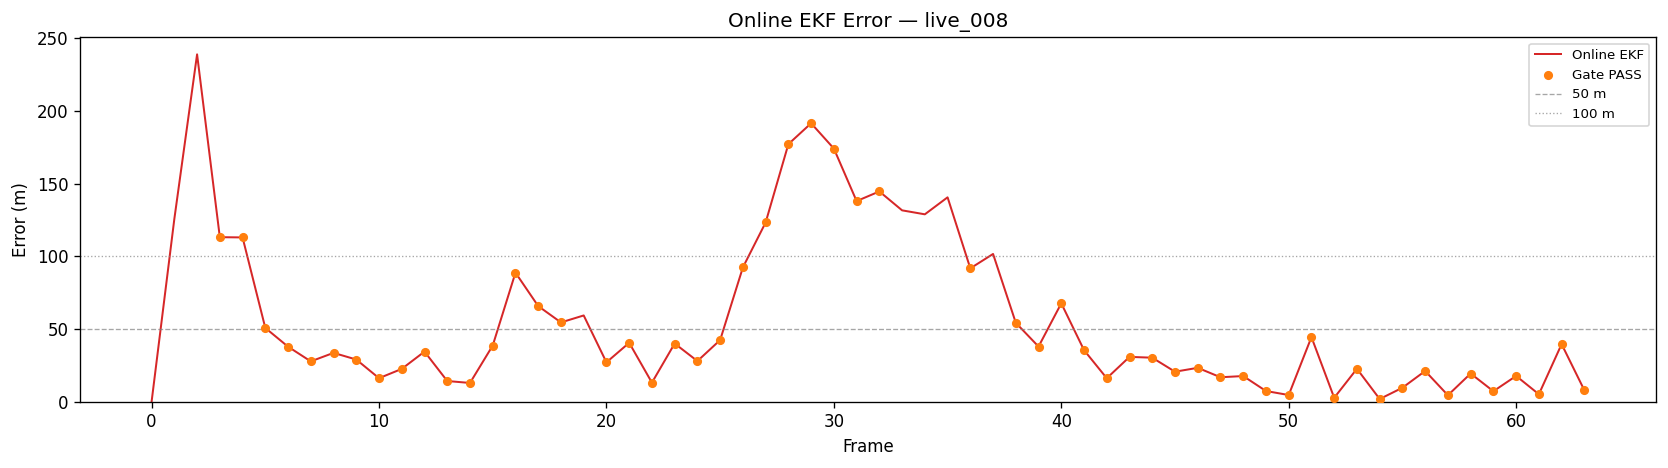

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
xs = results["frame_idx"]
ax.plot(xs, results["online_err_m"], color="tab:red", lw=1.2, label="Online EKF")
ax.scatter(xs[gate], results["online_err_m"][gate], s=20, color="tab:orange",
           zorder=5, label="Gate PASS")
ax.axhline(50,  color="gray", lw=0.8, ls="--", alpha=0.7, label="50 m")
ax.axhline(100, color="gray", lw=0.8, ls=":",  alpha=0.7, label="100 m")
ax.set_xlabel("Frame")
ax.set_ylabel("Error (m)")
ax.set_title(f"Online EKF Error — {meta.get('run_id', RUN_DIR.name)}")
ax.legend(fontsize=8)
ax.set_ylim(bottom=0)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(OUT_DIR / "error_over_time.png")
    print(f"Saved → {OUT_DIR}/error_over_time.png")
plt.show()

Saved → C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\analysis\live_008/trajectory_map.png


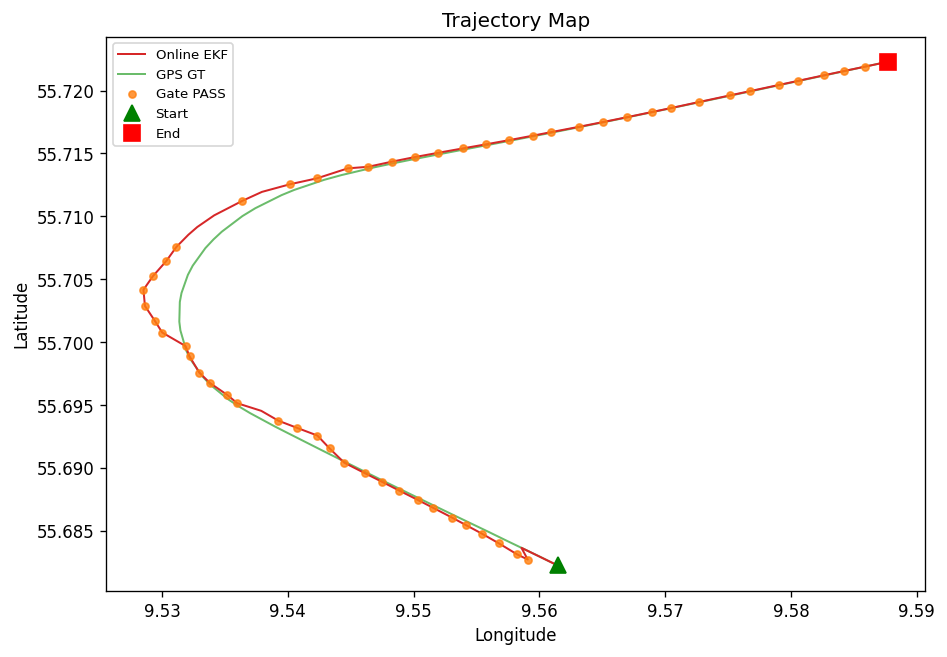

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
gt_valid = results[have_gt]
ax.plot(results["final_lon"], results["final_lat"],
        color="tab:red", lw=1.2, label="Online EKF", zorder=3)
if len(gt_valid):
    ax.plot(gt_valid["gps_lon"], gt_valid["gps_lat"],
            color="tab:green", lw=1.2, alpha=0.7, label="GPS GT", zorder=2)
gate_rows = results[gate]
ax.scatter(gate_rows["final_lon"], gate_rows["final_lat"],
           s=18, c="tab:orange", zorder=5, label="Gate PASS", alpha=0.8)
ax.plot(results["final_lon"].iloc[0], results["final_lat"].iloc[0],
        "g^", ms=10, zorder=6, label="Start")
ax.plot(results["final_lon"].iloc[-1], results["final_lat"].iloc[-1],
        "rs", ms=10, zorder=6, label="End")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Trajectory Map")
ax.legend(fontsize=8)
ax.set_aspect("equal")
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(OUT_DIR / "trajectory_map.png")
    print(f"Saved → {OUT_DIR}/trajectory_map.png")
plt.show()

Saved → C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\analysis\live_008/gate_health.png


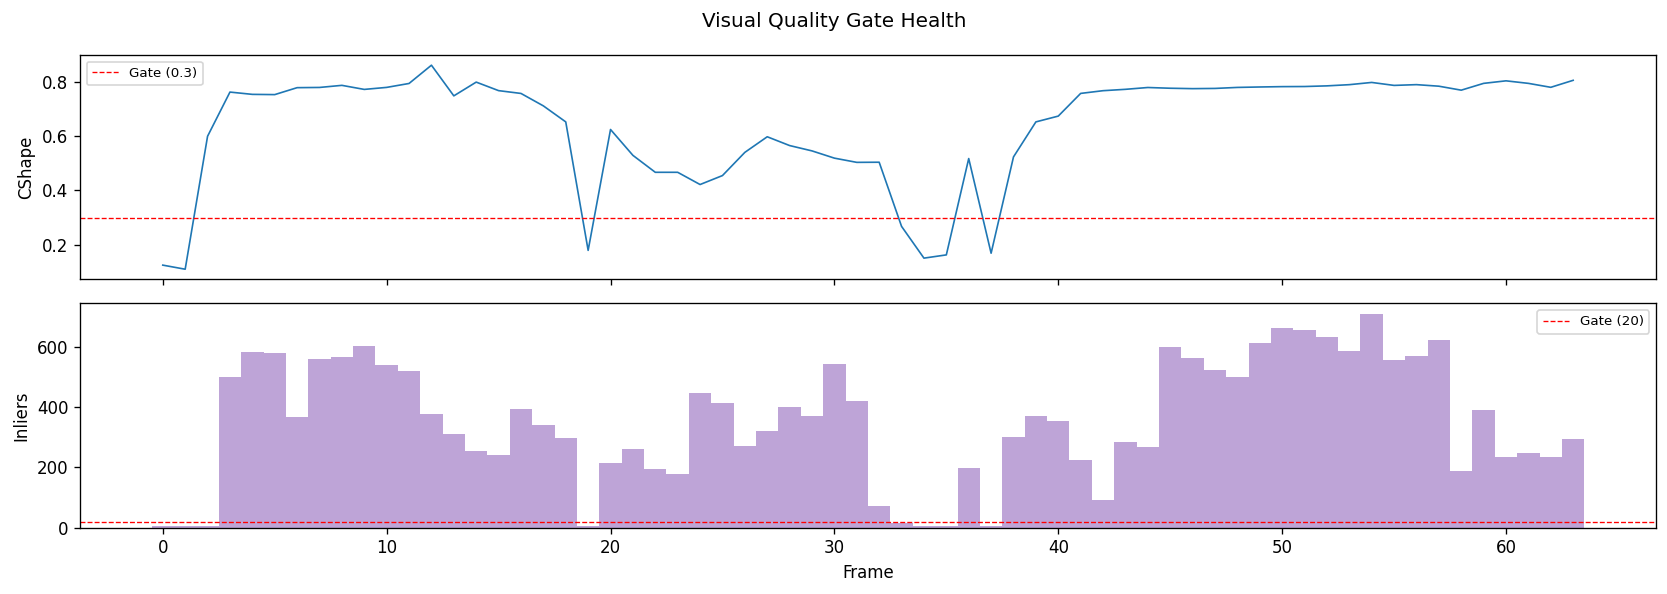

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
xs = results["frame_idx"]
ax1.plot(xs, results["cs_shape"], color="tab:blue", lw=1)
ax1.axhline(config.QUALITY_GATE_CSHAPE, color="red", ls="--", lw=0.8,
            label=f"Gate ({config.QUALITY_GATE_CSHAPE})")
ax1.set_ylabel("CShape")
ax1.legend(fontsize=8)
ax2.bar(xs, results["inliers"], color="tab:purple", alpha=0.6, width=1)
ax2.axhline(config.QUALITY_GATE_INLIERS, color="red", ls="--", lw=0.8,
            label=f"Gate ({config.QUALITY_GATE_INLIERS})")
ax2.set_ylabel("Inliers")
ax2.set_xlabel("Frame")
ax2.legend(fontsize=8)
plt.suptitle("Visual Quality Gate Health")
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(OUT_DIR / "gate_health.png")
    print(f"Saved → {OUT_DIR}/gate_health.png")
plt.show()

Saved → C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\analysis\live_008/ekf_sigma.png


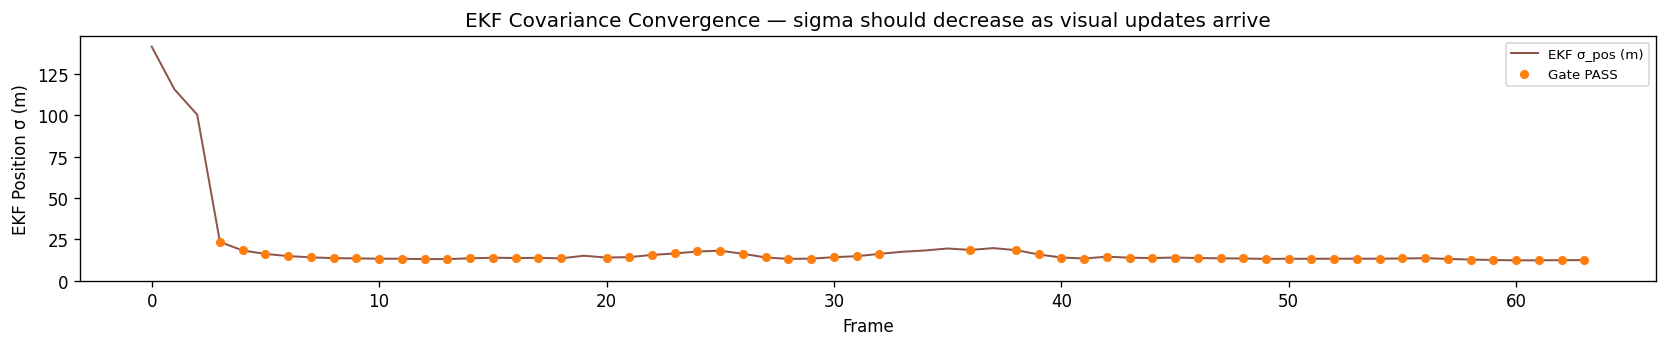

In [8]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(results["frame_idx"], results["ekf_pos_sigma"],
        color="tab:brown", lw=1.2, label="EKF \u03c3_pos (m)")
ax.scatter(results["frame_idx"][gate], results["ekf_pos_sigma"][gate],
           s=20, color="tab:orange", zorder=5, label="Gate PASS")
ax.set_xlabel("Frame")
ax.set_ylabel("EKF Position \u03c3 (m)")
ax.set_title("EKF Covariance Convergence — sigma should decrease as visual updates arrive")
ax.legend(fontsize=8)
ax.set_ylim(bottom=0)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(OUT_DIR / "ekf_sigma.png")
    print(f"Saved → {OUT_DIR}/ekf_sigma.png")
plt.show()

Saved → C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\analysis\live_008/error_cdf.png


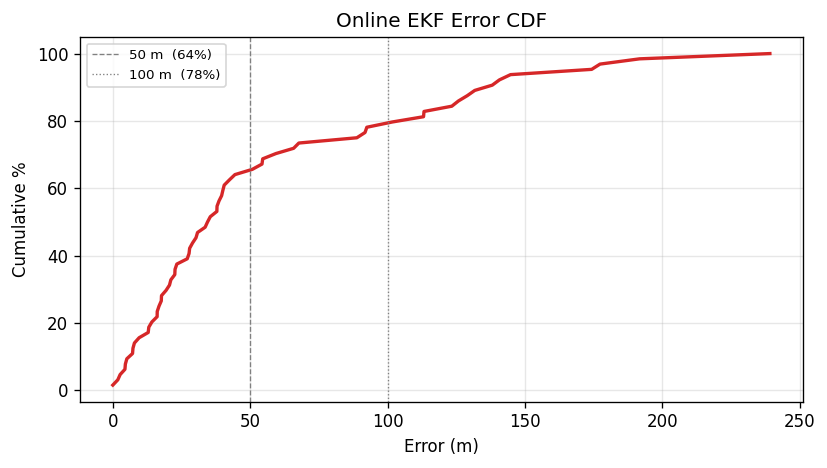

In [9]:
errs_sorted = results["online_err_m"].dropna().sort_values()
if len(errs_sorted):
    fig, ax = plt.subplots(figsize=(7, 4))
    cdf = np.arange(1, len(errs_sorted) + 1) / len(errs_sorted)
    ax.plot(errs_sorted, cdf * 100, color="tab:red", lw=2)
    for thresh, ls in [(50, "--"), (100, ":")]:
        pct_at = float(np.mean(errs_sorted <= thresh) * 100)
        ax.axvline(thresh, color="gray", ls=ls, lw=0.8,
                   label=f"{thresh} m  ({pct_at:.0f}%)")
    ax.set_xlabel("Error (m)")
    ax.set_ylabel("Cumulative %")
    ax.set_title("Online EKF Error CDF")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if SAVE_FIGS:
        fig.savefig(OUT_DIR / "error_cdf.png")
        print(f"Saved → {OUT_DIR}/error_cdf.png")
    plt.show()
else:
    print("No GT data available — CDF skipped")

Saved → C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\analysis\live_008/timing.png


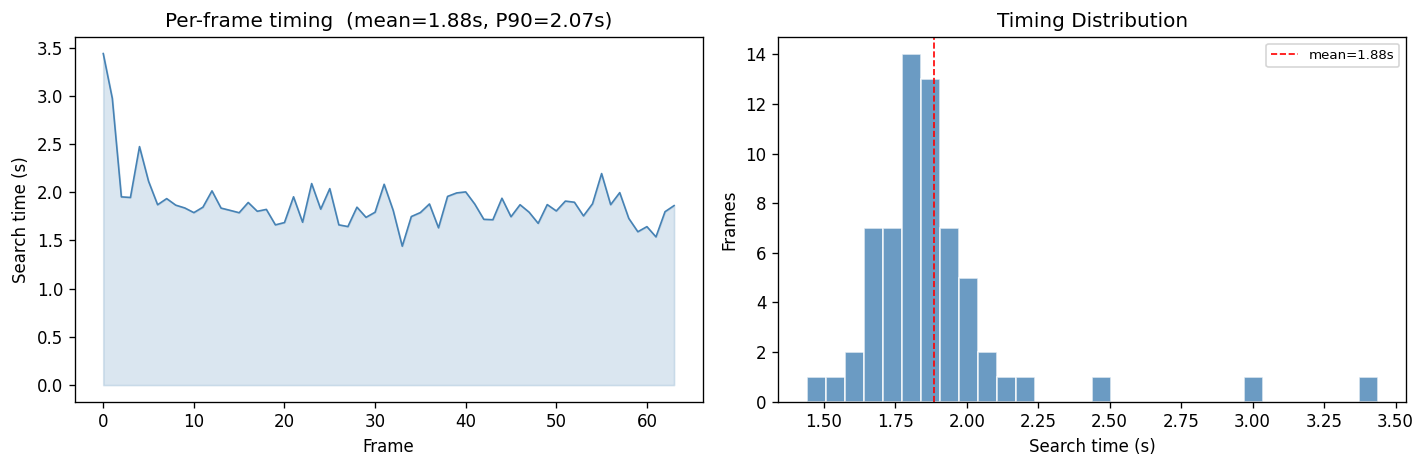


Tiles tested — mean: 7.4  max: 10
Verification matches — mean: 466.9

End-to-end latency (frame capture → GPS estimate):
  mean=2357ms  median=2268ms  P90=2724ms  max=4019ms


In [10]:
st = results["search_time_s"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(results["frame_idx"], st, color="steelblue", lw=1)
ax1.fill_between(results["frame_idx"], st, alpha=0.2, color="steelblue")
ax1.set_xlabel("Frame")
ax1.set_ylabel("Search time (s)")
ax1.set_title(f"Per-frame timing  (mean={st.mean():.2f}s, P90={st.quantile(0.9):.2f}s)")
ax2.hist(st, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
ax2.axvline(st.mean(), color="red", ls="--", lw=1, label=f"mean={st.mean():.2f}s")
ax2.set_xlabel("Search time (s)")
ax2.set_ylabel("Frames")
ax2.legend(fontsize=8)
ax2.set_title("Timing Distribution")
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(OUT_DIR / "timing.png")
    print(f"Saved → {OUT_DIR}/timing.png")
plt.show()
print(f"\nTiles tested — mean: {results['tiles_tested'].mean():.1f}  max: {results['tiles_tested'].max()}")
print(f"Verification matches — mean: {results['verification_matches'].mean():.1f}")
if "inference_ms" in results.columns and results["inference_ms"].notna().any():
    inf = results["inference_ms"].dropna()
    print(f"\nEnd-to-end latency (frame capture → GPS estimate):")
    print(f"  mean={inf.mean():.0f}ms  median={inf.median():.0f}ms  P90={inf.quantile(0.9):.0f}ms  max={inf.max():.0f}ms")